# 06 - Ground-Truth Station Collection and Target Selection

This notebook adds an independent rain-gauge reference layer, then uses it to decide which rainfall target candidate is most defensible for model training.

The notebook uses NOAA GHCN-Daily direct files, which do not require an API key. It collects station metadata, selects nearby PRCP stations for each canonical city, downloads daily station files, aggregates station observations into an entity-date ground-truth table, and compares the five existing target candidates against this station reference.

Leakage rule: target selection uses only `train` and `validation` rows. The `test` split remains untouched.

## 1. Setup

In [10]:
from pathlib import Path
from datetime import datetime, timezone
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen
import hashlib
import json
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)


def resolve_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name.lower() == 'notebooks' and (candidate.parent / 'data').exists():
            return candidate.parent
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    fallback = Path(r'D:\DS\Project').resolve()
    if (fallback / 'data').exists() and (fallback / 'notebooks').exists():
        return fallback
    raise FileNotFoundError('Could not resolve project root containing data/ and notebooks/.')


BASE_DIR = resolve_project_root()
print('Project root:', BASE_DIR)

DATA_DIR = BASE_DIR / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_READY_DIR = PROCESSED_DIR / 'model_ready'
GROUNDTRUTH_DIR = DATA_DIR / 'groundtruth'
CACHE_DIR = GROUNDTRUTH_DIR / 'cache' / 'ghcnd'

REPORT_DIR = BASE_DIR / 'reports' / '06_groundtruth_target_selection'
TABLE_DIR = REPORT_DIR / 'tables'
FIGURE_DIR = REPORT_DIR / 'figures'

for directory in [GROUNDTRUTH_DIR, CACHE_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

START_DATE = '2020-01-01'
END_DATE = '2025-12-31'
DATE_INDEX = pd.date_range(START_DATE, END_DATE, freq='D')
BASE_STEM = 'sea_station_rainfall_daily_2020_2025'

PRIMARY_RADIUS_KM = 100
FALLBACK_RADIUS_KM = 300
MAX_CANDIDATE_STATIONS_PER_ENTITY = 10
MAX_SELECTED_STATIONS_PER_ENTITY = 3
MIN_STATION_COVERAGE = 0.60
MIN_CITY_MONTH_PAIRED_DAYS = 30
WET_DAY_THRESHOLD_MM = 1.0

GHCN_BASE_URL = 'https://www.ncei.noaa.gov/pub/data/ghcn/daily'
GHCN_STATIONS_URL = f'{GHCN_BASE_URL}/ghcnd-stations.txt'
GHCN_INVENTORY_URL = f'{GHCN_BASE_URL}/ghcnd-inventory.txt'
GHCN_ALL_URL = f'{GHCN_BASE_URL}/all'

REGISTRY_PATH = RAW_DIR / 'sea_rainfall_daily_2020_2025_entity_registry.csv'
TARGETS_PATH = MODEL_READY_DIR / 'sea_rainfall_daily_2020_2025_model_ready_targets_y.csv'

GROUNDTRUTH_OBSERVATIONS_PATH = GROUNDTRUTH_DIR / f'{BASE_STEM}_station_observations.csv'
GROUNDTRUTH_ENTITY_PATH = GROUNDTRUTH_DIR / f'{BASE_STEM}_entity_groundtruth.csv'
GROUNDTRUTH_REGISTRY_PATH = GROUNDTRUTH_DIR / f'{BASE_STEM}_station_registry.csv'
GROUNDTRUTH_MANIFEST_PATH = GROUNDTRUTH_DIR / f'{BASE_STEM}_manifest.json'

TARGET_COLS = [
    'target_nasa_power_precipitation_mm',
    'target_open_meteo_precipitation_mm',
    'target_baseline_two_source_mean_mm',
    'target_nasa_reference_consensus_mm',
    'target_open_meteo_reference_consensus_mm',
]

TARGET_LABELS = {
    'target_nasa_power_precipitation_mm': 'NASA POWER raw',
    'target_open_meteo_precipitation_mm': 'Open-Meteo raw',
    'target_baseline_two_source_mean_mm': 'Two-source mean',
    'target_nasa_reference_consensus_mm': 'NASA-reference consensus',
    'target_open_meteo_reference_consensus_mm': 'Open-Meteo-reference consensus',
}

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 220,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

if not REGISTRY_PATH.exists():
    raise FileNotFoundError(f'Missing entity registry: {REGISTRY_PATH}')
if not TARGETS_PATH.exists():
    raise FileNotFoundError(f'Missing model-ready target table: {TARGETS_PATH}')


Project root: D:\DS\Project


## 2. Download and Parse NOAA GHCN-Daily Metadata

GHCN-Daily stores daily station observations. The element used here is `PRCP`, whose unit is tenths of millimeters. The conversion is:

`station_precipitation_mm = PRCP / 10`

In [11]:
def download_file(url, path, timeout=120, max_retries=4, pause_seconds=2):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        return path

    tmp_path = path.with_suffix(path.suffix + '.tmp')
    request = Request(url, headers={'User-Agent': 'ds108-rainfall-groundtruth/1.0 no-api-key'})
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            with urlopen(request, timeout=timeout) as response, tmp_path.open('wb') as file:
                while True:
                    chunk = response.read(1024 * 1024)
                    if not chunk:
                        break
                    file.write(chunk)
            tmp_path.replace(path)
            return path
        except (HTTPError, URLError, TimeoutError, OSError) as error:
            last_error = error
            if tmp_path.exists():
                tmp_path.unlink()
            if attempt == max_retries:
                break
            time.sleep(pause_seconds * attempt)
    raise RuntimeError(f'Failed to download {url}: {last_error}')


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0088
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    a = math.sin(delta_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    return radius_km * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def parse_ghcnd_stations(path):
    rows = []
    with Path(path).open('r', encoding='latin-1') as file:
        for line in file:
            rows.append({
                'station_id': line[0:11].strip(),
                'station_latitude': float(line[12:20]),
                'station_longitude': float(line[21:30]),
                'station_elevation_m': pd.to_numeric(line[31:37].strip(), errors='coerce'),
                'station_state': line[38:40].strip(),
                'station_name': line[41:71].strip(),
                'gsn_flag': line[72:75].strip(),
                'hcn_crn_flag': line[76:79].strip(),
                'wmo_id': line[80:85].strip(),
            })
    return pd.DataFrame(rows)


def parse_ghcnd_inventory(path):
    rows = []
    with Path(path).open('r', encoding='latin-1') as file:
        for line in file:
            rows.append({
                'station_id': line[0:11].strip(),
                'inventory_latitude': float(line[12:20]),
                'inventory_longitude': float(line[21:30]),
                'element': line[31:35].strip(),
                'first_year': int(line[36:40]),
                'last_year': int(line[41:45]),
            })
    return pd.DataFrame(rows)


stations_path = download_file(GHCN_STATIONS_URL, CACHE_DIR / 'ghcnd-stations.txt')
inventory_path = download_file(GHCN_INVENTORY_URL, CACHE_DIR / 'ghcnd-inventory.txt')

stations = parse_ghcnd_stations(stations_path)
inventory = parse_ghcnd_inventory(inventory_path)

prcp_inventory = inventory[
    (inventory['element'].eq('PRCP'))
    & (inventory['first_year'] <= int(START_DATE[:4]))
    & (inventory['last_year'] >= int(END_DATE[:4]))
].copy()

prcp_stations = stations.merge(
    prcp_inventory[['station_id', 'first_year', 'last_year']],
    on='station_id',
    how='inner',
)

print(f'GHCN stations with PRCP coverage through {START_DATE[:4]}-{END_DATE[:4]}: {len(prcp_stations):,}')
prcp_stations.head()


GHCN stations with PRCP coverage through 2020-2025: 30,470


,station_id,station_latitude,station_longitude,station_elevation_m,station_state,station_name,gsn_flag,hcn_crn_flag,wmo_id,first_year,last_year
0,AE000041196,25.3330,55.517,34.0,,SHARJAH INTER. AIRP,GSN,,41196,1944,2025
1,AEM00041194,25.2550,55.364,10.4,,DUBAI INTL,,,41194,1983,2025
2,AEM00041217,24.4330,54.651,26.8,,ABU DHABI INTL,,,41217,1984,2025
3,AEM00041218,24.2620,55.609,264.9,,AL AIN INTL,,,41218,1994,2025
4,AG000060390,36.7167,3.250,24.0,,ALGER-DAR EL BEIDA,GSN,,60390,1940,2025


## 3. Select Candidate Stations Near Each Canonical City

In [12]:
entity_registry = pd.read_csv(REGISTRY_PATH)

candidate_rows = []
for _, entity in entity_registry.iterrows():
    candidates = prcp_stations.copy()
    candidates['entity_id'] = entity['entity_id']
    candidates['country'] = entity['country']
    candidates['location_name'] = entity['location_name']
    candidates['canonical_latitude'] = entity['canonical_latitude']
    candidates['canonical_longitude'] = entity['canonical_longitude']
    candidates['distance_to_city_km'] = candidates.apply(
        lambda row: haversine_km(
            entity['canonical_latitude'],
            entity['canonical_longitude'],
            row['station_latitude'],
            row['station_longitude'],
        ),
        axis=1,
    )
    near = candidates[candidates['distance_to_city_km'] <= PRIMARY_RADIUS_KM].copy()
    if near.empty:
        near = candidates[candidates['distance_to_city_km'] <= FALLBACK_RADIUS_KM].copy()
    if near.empty:
        near = candidates.nsmallest(MAX_CANDIDATE_STATIONS_PER_ENTITY, 'distance_to_city_km').copy()
    else:
        near = near.nsmallest(MAX_CANDIDATE_STATIONS_PER_ENTITY, 'distance_to_city_km').copy()
    near['candidate_rank_by_distance'] = range(1, len(near) + 1)
    candidate_rows.append(near)

station_candidates = pd.concat(candidate_rows, ignore_index=True)
station_candidates = station_candidates[
    [
        'entity_id', 'country', 'location_name', 'canonical_latitude', 'canonical_longitude',
        'station_id', 'station_name', 'station_latitude', 'station_longitude', 'station_elevation_m',
        'wmo_id', 'first_year', 'last_year', 'distance_to_city_km', 'candidate_rank_by_distance',
    ]
].sort_values(['entity_id', 'candidate_rank_by_distance']).reset_index(drop=True)

station_candidates.to_csv(TABLE_DIR / '01_station_candidates_by_distance.csv', index=False)
station_candidates.head(20)


,entity_id,country,location_name,canonical_latitude,canonical_longitude,station_id,station_name,station_latitude,station_longitude,station_elevation_m,wmo_id,first_year,last_year,distance_to_city_km,candidate_rank_by_distance
0,SEA_BN_BANDAR_SERI_BEGAWAN,Brunei,Bandar Seri Begawan,4.9031,114.9398,BXM00096315,BRUNEI INTL,4.9440,114.928,22.3,96315,1981,2025,4.732032,1
1,SEA_BN_BANDAR_SERI_BEGAWAN,Brunei,Bandar Seri Begawan,4.9031,114.9398,MY000096465,LABUAN,5.3000,115.250,30.0,96465,1955,2025,55.929292,2
2,SEA_ID_JAKARTA,Indonesia,Jakarta,-6.2088,106.8456,IDM00096749,SOEKARNO HATTA INTL,-6.1260,106.656,10.4,96749,1986,2025,22.893520,1
3,SEA_ID_JAKARTA,Indonesia,Jakarta,-6.2088,106.8456,IDM00096739,BUDIARTO,-6.2930,106.570,47.0,96739,1973,2025,31.869469,2
4,SEA_KH_PHNOM_PENH,Cambodia,Phnom Penh,11.5564,104.9282,CBM00048991,PHNOM PENH INTL,11.5470,104.844,12.2,48991,1950,2025,9.232339,1
5,SEA_LA_VIENTIANE,Laos,Vientiane,17.9757,102.6331,LAM00048940,WATTAY INTL,17.9880,102.563,171.9,48940,1950,2025,7.539132,1
6,SEA_LA_VIENTIANE,Laos,Vientiane,17.9757,102.6331,THW00041018,UDON THANI,17.3833,102.800,178.0,48354,1943,2025,68.203837,2
7,SEA_MM_YANGON,Myanmar,Yangon,16.8409,96.1735,BMM00048097,YANGON INTL,16.9070,96.133,33.2,48097,1954,2025,8.520229,1
8,SEA_MY_KUALA_LUMPUR,Malaysia,Kuala Lumpur,3.1390,101.6869,MYM00048647,SULTAN ABDUL AZIZ SHAH INTL,3.1310,101.549,27.4,48647,1949,2025,15.336674,1
9,SEA_MY_KUALA_LUMPUR,Malaysia,Kuala Lumpur,3.1390,101.6869,MYM00048650,KUALA LUMPUR INTL,2.7460,101.710,21.0,48650,2005,2025,43.774892,2


## 4. Download Candidate Station Daily Files and Compute Coverage

In [13]:
def parse_station_dly_prcp(path, station_id):
    rows = []
    with Path(path).open('r', encoding='latin-1') as file:
        for line in file:
            if line[0:11].strip() != station_id:
                continue
            year = int(line[11:15])
            month = int(line[15:17])
            element = line[17:21].strip()
            if element != 'PRCP' or year < int(START_DATE[:4]) or year > int(END_DATE[:4]):
                continue
            for day in range(1, 32):
                start = 21 + (day - 1) * 8
                value_raw = int(line[start:start + 5])
                measurement_flag = line[start + 5:start + 6].strip()
                quality_flag = line[start + 6:start + 7].strip()
                source_flag = line[start + 7:start + 8].strip()
                try:
                    date = pd.Timestamp(year=year, month=month, day=day)
                except ValueError:
                    continue
                if date < DATE_INDEX.min() or date > DATE_INDEX.max():
                    continue
                if value_raw == -9999 or quality_flag:
                    precipitation_mm = np.nan
                else:
                    precipitation_mm = value_raw / 10.0
                rows.append({
                    'station_id': station_id,
                    'date': date,
                    'station_precipitation_mm': precipitation_mm,
                    'ghcn_value_raw_tenths_mm': value_raw,
                    'measurement_flag': measurement_flag,
                    'quality_flag': quality_flag,
                    'source_flag': source_flag,
                })
    return pd.DataFrame(rows)


station_daily_frames = []
download_status_rows = []
for index, station_id in enumerate(sorted(station_candidates['station_id'].unique()), start=1):
    station_url = f'{GHCN_ALL_URL}/{station_id}.dly'
    station_path = CACHE_DIR / f'{station_id}.dly'
    print(f'[{index:03d}/{station_candidates["station_id"].nunique():03d}] {station_id}')
    try:
        download_file(station_url, station_path, timeout=90, max_retries=3)
        station_daily = parse_station_dly_prcp(station_path, station_id)
        station_daily_frames.append(station_daily)
        download_status_rows.append({'station_id': station_id, 'download_status': 'ok', 'rows': len(station_daily), 'path': str(station_path.relative_to(BASE_DIR))})
    except Exception as error:
        download_status_rows.append({'station_id': station_id, 'download_status': 'failed', 'rows': 0, 'path': '', 'error': str(error)})

raw_station_daily = pd.concat(station_daily_frames, ignore_index=True) if station_daily_frames else pd.DataFrame()
download_status = pd.DataFrame(download_status_rows)

coverage_rows = []
for _, candidate in station_candidates.iterrows():
    station_id = candidate['station_id']
    station_values = raw_station_daily[raw_station_daily['station_id'].eq(station_id)][['date', 'station_precipitation_mm']]
    full = pd.DataFrame({'date': DATE_INDEX}).merge(station_values, on='date', how='left')
    valid_days = int(full['station_precipitation_mm'].notna().sum())
    coverage_rows.append({
        **candidate.to_dict(),
        'valid_prcp_days': valid_days,
        'expected_days': len(DATE_INDEX),
        'coverage_ratio': valid_days / len(DATE_INDEX),
    })

station_coverage = pd.DataFrame(coverage_rows)
station_coverage.to_csv(TABLE_DIR / '02_station_candidate_coverage.csv', index=False)
download_status.to_csv(TABLE_DIR / '03_station_download_status.csv', index=False)
station_coverage.head(20)


[001/023] BMM00048097
[002/023] BXM00096315
[003/023] CBM00048991
[004/023] CHM00059417
[005/023] ID000097372
[006/023] IDM00096091
[007/023] IDM00096739
[008/023] IDM00096749
[009/023] IDM00097310
[010/023] IDM00097320
[011/023] LAM00048940
[012/023] MY000096465
[013/023] MYM00048647
[014/023] MYM00048650
[015/023] RP000098429
[016/023] RP000098430
[017/023] SNM00048698
[018/023] TH000048430
[019/023] TH000048456
[020/023] TH000048459
[021/023] THW00041018
[022/023] VMM00048845
[023/023] VMM00048917


,entity_id,country,location_name,canonical_latitude,canonical_longitude,station_id,station_name,station_latitude,station_longitude,station_elevation_m,wmo_id,first_year,last_year,distance_to_city_km,candidate_rank_by_distance,valid_prcp_days,expected_days,coverage_ratio
0,SEA_BN_BANDAR_SERI_BEGAWAN,Brunei,Bandar Seri Begawan,4.9031,114.9398,BXM00096315,BRUNEI INTL,4.9440,114.928,22.3,96315,1981,2025,4.732032,1,1613,2192,0.735858
1,SEA_BN_BANDAR_SERI_BEGAWAN,Brunei,Bandar Seri Begawan,4.9031,114.9398,MY000096465,LABUAN,5.3000,115.250,30.0,96465,1955,2025,55.929292,2,1613,2192,0.735858
2,SEA_ID_JAKARTA,Indonesia,Jakarta,-6.2088,106.8456,IDM00096749,SOEKARNO HATTA INTL,-6.1260,106.656,10.4,96749,1986,2025,22.893520,1,29,2192,0.013230
3,SEA_ID_JAKARTA,Indonesia,Jakarta,-6.2088,106.8456,IDM00096739,BUDIARTO,-6.2930,106.570,47.0,96739,1973,2025,31.869469,2,40,2192,0.018248
4,SEA_KH_PHNOM_PENH,Cambodia,Phnom Penh,11.5564,104.9282,CBM00048991,PHNOM PENH INTL,11.5470,104.844,12.2,48991,1950,2025,9.232339,1,644,2192,0.293796
5,SEA_LA_VIENTIANE,Laos,Vientiane,17.9757,102.6331,LAM00048940,WATTAY INTL,17.9880,102.563,171.9,48940,1950,2025,7.539132,1,684,2192,0.312044
6,SEA_LA_VIENTIANE,Laos,Vientiane,17.9757,102.6331,THW00041018,UDON THANI,17.3833,102.800,178.0,48354,1943,2025,68.203837,2,982,2192,0.447993
7,SEA_MM_YANGON,Myanmar,Yangon,16.8409,96.1735,BMM00048097,YANGON INTL,16.9070,96.133,33.2,48097,1954,2025,8.520229,1,567,2192,0.258668
8,SEA_MY_KUALA_LUMPUR,Malaysia,Kuala Lumpur,3.1390,101.6869,MYM00048647,SULTAN ABDUL AZIZ SHAH INTL,3.1310,101.549,27.4,48647,1949,2025,15.336674,1,1642,2192,0.749088
9,SEA_MY_KUALA_LUMPUR,Malaysia,Kuala Lumpur,3.1390,101.6869,MYM00048650,KUALA LUMPUR INTL,2.7460,101.710,21.0,48650,2005,2025,43.774892,2,1554,2192,0.708942


## 5. Select Stations and Build Entity-Date Ground Truth

If enough station coverage exists, up to three stations per city are selected. If no station reaches the minimum coverage threshold, the notebook keeps the best available station and marks the selection as low coverage.

In [14]:
selected_station_rows = []
for entity_id, group in station_coverage.groupby('entity_id'):
    eligible = group[group['coverage_ratio'] >= MIN_STATION_COVERAGE].copy()
    if eligible.empty:
        chosen = group.sort_values(['coverage_ratio', 'distance_to_city_km'], ascending=[False, True]).head(1).copy()
        chosen['station_selection_status'] = 'best_available_below_minimum_coverage'
    else:
        chosen = eligible.sort_values(['distance_to_city_km', 'coverage_ratio'], ascending=[True, False]).head(MAX_SELECTED_STATIONS_PER_ENTITY).copy()
        chosen['station_selection_status'] = 'selected_coverage_ok'
    chosen['selected_station_rank'] = range(1, len(chosen) + 1)
    selected_station_rows.append(chosen)

selected_stations = pd.concat(selected_station_rows, ignore_index=True)
selected_stations.to_csv(GROUNDTRUTH_REGISTRY_PATH, index=False)
selected_stations.to_csv(TABLE_DIR / '04_selected_station_registry.csv', index=False)

station_observation_frames = []
for _, station in selected_stations.iterrows():
    station_id = station['station_id']
    station_values = raw_station_daily[raw_station_daily['station_id'].eq(station_id)].copy()
    full = pd.DataFrame({'date': DATE_INDEX}).merge(station_values, on='date', how='left')
    for column in ['station_id', 'station_name', 'station_latitude', 'station_longitude', 'station_elevation_m', 'wmo_id']:
        full[column] = station[column]
    for column in ['entity_id', 'country', 'location_name', 'canonical_latitude', 'canonical_longitude']:
        full[column] = station[column]
    full['distance_to_city_km'] = station['distance_to_city_km']
    full['station_coverage_ratio'] = station['coverage_ratio']
    full['station_selection_status'] = station['station_selection_status']
    full['selected_station_rank'] = station['selected_station_rank']
    station_observation_frames.append(full)

station_observations = pd.concat(station_observation_frames, ignore_index=True)

valid_station_observations = station_observations.dropna(subset=['station_precipitation_mm']).copy()
valid_station_observations['distance_weight'] = 1 / np.square(valid_station_observations['distance_to_city_km'] + 1)
valid_station_observations['weighted_precipitation'] = valid_station_observations['station_precipitation_mm'] * valid_station_observations['distance_weight']

groundtruth_agg = (
    valid_station_observations
    .groupby(['entity_id', 'date'], as_index=False)
    .agg(
        weighted_precipitation_sum=('weighted_precipitation', 'sum'),
        weight_sum=('distance_weight', 'sum'),
        groundtruth_station_count=('station_id', 'nunique'),
        nearest_station_distance_km=('distance_to_city_km', 'min'),
    )
)
groundtruth_agg['groundtruth_precipitation_mm'] = groundtruth_agg['weighted_precipitation_sum'] / groundtruth_agg['weight_sum']

entity_date_grid = entity_registry[['entity_id', 'country', 'location_name', 'canonical_latitude', 'canonical_longitude']].merge(
    pd.DataFrame({'date': DATE_INDEX}), how='cross'
)
entity_groundtruth = entity_date_grid.merge(
    groundtruth_agg[['entity_id', 'date', 'groundtruth_precipitation_mm', 'groundtruth_station_count', 'nearest_station_distance_km']],
    on=['entity_id', 'date'],
    how='left',
)
entity_groundtruth['groundtruth_method'] = 'inverse_distance_weighted_selected_ghcn_prcp_stations'
entity_groundtruth['date'] = pd.to_datetime(entity_groundtruth['date'])

station_observations.to_csv(GROUNDTRUTH_OBSERVATIONS_PATH, index=False)
entity_groundtruth.to_csv(GROUNDTRUTH_ENTITY_PATH, index=False)

groundtruth_quality_by_entity = (
    entity_groundtruth
    .groupby(['entity_id', 'country', 'location_name'], as_index=False)
    .agg(
        groundtruth_valid_days=('groundtruth_precipitation_mm', lambda s: int(s.notna().sum())),
        expected_days=('date', 'size'),
        selected_station_days_mean=('groundtruth_station_count', 'mean'),
        nearest_station_distance_km=('nearest_station_distance_km', 'min'),
    )
)
groundtruth_quality_by_entity['groundtruth_coverage_ratio'] = groundtruth_quality_by_entity['groundtruth_valid_days'] / groundtruth_quality_by_entity['expected_days']
groundtruth_quality_by_entity = groundtruth_quality_by_entity.merge(
    selected_stations.groupby('entity_id').agg(selected_station_count=('station_id', 'nunique')).reset_index(),
    on='entity_id',
    how='left',
)
groundtruth_quality_by_entity.to_csv(TABLE_DIR / '05_groundtruth_quality_by_entity.csv', index=False)

groundtruth_quality_by_entity.sort_values('groundtruth_coverage_ratio')


,entity_id,country,location_name,groundtruth_valid_days,expected_days,selected_station_days_mean,nearest_station_distance_km,groundtruth_coverage_ratio,selected_station_count
1,SEA_ID_JAKARTA,Indonesia,Jakarta,40,2192,1.000000,31.869469,0.018248,1
9,SEA_TL_DILI,Timor-Leste,Dili,58,2192,1.000000,115.620590,0.026460,1
4,SEA_MM_YANGON,Myanmar,Yangon,567,2192,1.000000,8.520229,0.258668,1
2,SEA_KH_PHNOM_PENH,Cambodia,Phnom Penh,644,2192,1.000000,9.232339,0.293796,1
3,SEA_LA_VIENTIANE,Laos,Vientiane,982,2192,1.000000,68.203837,0.447993,1
8,SEA_TH_BANGKOK,Thailand,Bangkok,1075,2192,1.000000,20.777770,0.490420,1
6,SEA_PH_MANILA,Philippines,Manila,1151,2192,1.000000,5.131365,0.525091,1
11,SEA_VN_HO_CHI_MINH,Vietnam,Ho Chi Minh City,1422,2192,1.000000,298.799833,0.648723,1
7,SEA_SG_SINGAPORE,Singapore,Singapore,1727,2192,1.000000,19.366206,0.787865,1
5,SEA_MY_KUALA_LUMPUR,Malaysia,Kuala Lumpur,1771,2192,1.804630,15.336674,0.807938,2


## 6. Compare the Five Target Candidates Against Station Ground Truth

In [15]:
targets_y = pd.read_csv(TARGETS_PATH, parse_dates=['date'])
missing_targets = sorted(set(TARGET_COLS) - set(targets_y.columns))
if missing_targets:
    raise ValueError(f'Missing target columns: {missing_targets}')

eval_df = targets_y.merge(
    entity_groundtruth[['entity_id', 'date', 'groundtruth_precipitation_mm', 'groundtruth_station_count', 'nearest_station_distance_km']],
    on=['entity_id', 'date'],
    how='left',
)
eval_selection = eval_df[eval_df['split'].isin(['train', 'validation'])].dropna(subset=['groundtruth_precipitation_mm']).copy()
eval_selection['month'] = eval_selection['date'].dt.month


def cohen_kappa_binary(a, b):
    a = np.asarray(a).astype(bool)
    b = np.asarray(b).astype(bool)
    if len(a) == 0:
        return np.nan
    observed = np.mean(a == b)
    p_yes_a, p_yes_b = np.mean(a), np.mean(b)
    p_no_a, p_no_b = 1 - p_yes_a, 1 - p_yes_b
    expected = p_yes_a * p_yes_b + p_no_a * p_no_b
    if math.isclose(1 - expected, 0.0):
        return np.nan
    return (observed - expected) / (1 - expected)


def safe_corr(a, b, method='pearson'):
    values = pd.DataFrame({'a': a, 'b': b}).dropna()
    if len(values) < 3 or values['a'].nunique() < 2 or values['b'].nunique() < 2:
        return np.nan
    return values['a'].corr(values['b'], method=method)


def station_metrics(frame, group_cols=None):
    group_cols = group_cols or []
    grouped = [((), frame)] if not group_cols else frame.groupby(group_cols, dropna=False)
    rows = []
    for key, group in grouped:
        key_tuple = key if isinstance(key, tuple) else (key,)
        base = dict(zip(group_cols, key_tuple))
        for target in TARGET_COLS:
            valid = group[[target, 'groundtruth_precipitation_mm']].dropna()
            if valid.empty:
                rows.append({**base, 'target': target, 'target_label': TARGET_LABELS[target], 'paired_n': 0})
                continue
            error = valid[target] - valid['groundtruth_precipitation_mm']
            rows.append({
                **base,
                'target': target,
                'target_label': TARGET_LABELS[target],
                'paired_n': int(len(valid)),
                'bias_mm_day': float(error.mean()),
                'mae_mm_day': float(error.abs().mean()),
                'rmse_mm_day': float(np.sqrt(np.mean(np.square(error)))),
                'pearson_r': float(safe_corr(valid[target], valid['groundtruth_precipitation_mm'], 'pearson')),
                'spearman_r': float(safe_corr(valid[target], valid['groundtruth_precipitation_mm'], 'spearman')),
                'wet_day_agreement_ratio': float(((valid[target] >= WET_DAY_THRESHOLD_MM) == (valid['groundtruth_precipitation_mm'] >= WET_DAY_THRESHOLD_MM)).mean()),
                'wet_day_kappa': float(cohen_kappa_binary(valid[target] >= WET_DAY_THRESHOLD_MM, valid['groundtruth_precipitation_mm'] >= WET_DAY_THRESHOLD_MM)),
            })
    return pd.DataFrame(rows)


if eval_selection.empty:
    metrics_overall = pd.DataFrame()
    metrics_by_city = pd.DataFrame()
    metrics_by_city_month = pd.DataFrame()
    print('No paired train/validation station ground-truth rows are available. Target selection cannot be computed.')
else:
    metrics_overall = station_metrics(eval_selection)
    metrics_by_city = station_metrics(eval_selection, ['country', 'location_name', 'entity_id'])
    metrics_by_city_month = station_metrics(eval_selection, ['country', 'location_name', 'entity_id', 'month'])

metrics_overall.to_csv(TABLE_DIR / '06_target_vs_groundtruth_overall_train_validation.csv', index=False)
metrics_by_city.to_csv(TABLE_DIR / '07_target_vs_groundtruth_by_city_train_validation.csv', index=False)
metrics_by_city_month.to_csv(TABLE_DIR / '08_target_vs_groundtruth_by_city_month_train_validation.csv', index=False)

metrics_overall.sort_values(['mae_mm_day', 'rmse_mm_day', 'bias_mm_day']) if not metrics_overall.empty else metrics_overall


,target,target_label,paired_n,bias_mm_day,mae_mm_day,rmse_mm_day,pearson_r,spearman_r,wet_day_agreement_ratio,wet_day_kappa
0,target_nasa_power_precipitation_mm,NASA POWER raw,11840,-0.219615,9.420677,17.644897,0.299855,0.470621,0.656503,0.302332
2,target_baseline_two_source_mean_mm,Two-source mean,11840,0.050838,9.454524,16.772416,0.320237,0.457823,0.641132,0.269373
4,target_open_meteo_reference_consensus_mm,Open-Meteo-reference consensus,11840,0.231958,9.479961,16.690660,0.329091,0.461933,0.633530,0.253422
3,target_nasa_reference_consensus_mm,NASA-reference consensus,11840,0.033584,9.585567,16.927638,0.305207,0.430090,0.631419,0.249572
1,target_open_meteo_precipitation_mm,Open-Meteo raw,11840,0.321291,10.271795,18.318925,0.241305,0.382980,0.632855,0.254956


## 7. Target Recommendation

In [16]:
if not metrics_overall.empty:
    ranked_overall = (
        metrics_overall
        .assign(abs_bias_mm_day=lambda d: d['bias_mm_day'].abs())
        .sort_values(['mae_mm_day', 'rmse_mm_day', 'abs_bias_mm_day'])
        .reset_index(drop=True)
    )
    best_target = ranked_overall.iloc[0]
    city_month_recommendation = (
        metrics_by_city_month
        .query('paired_n >= @MIN_CITY_MONTH_PAIRED_DAYS')
        .assign(abs_bias_mm_day=lambda d: d['bias_mm_day'].abs())
        .sort_values(['country', 'location_name', 'month', 'mae_mm_day', 'rmse_mm_day', 'abs_bias_mm_day'])
        .groupby(['country', 'location_name', 'entity_id', 'month'], as_index=False)
        .first()
        .rename(columns={'target': 'recommended_target', 'target_label': 'recommended_target_label'})
    )
else:
    ranked_overall = pd.DataFrame()
    best_target = None
    city_month_recommendation = pd.DataFrame()

decision_rows = []
if best_target is None:
    decision_rows.append({
        'decision_item': 'primary_target',
        'value': 'not_selected',
        'rationale': 'No station ground-truth rows were available after collection.',
    })
else:
    decision_rows.extend([
        {
            'decision_item': 'primary_target',
            'value': best_target['target'],
            'label': best_target['target_label'],
            'rationale': 'Lowest train/validation MAE against independent GHCN-Daily station ground truth; tie-broken by RMSE and absolute bias.',
        },
        {'decision_item': 'mae_mm_day', 'value': round(float(best_target['mae_mm_day']), 4), 'rationale': 'Computed on train/validation only.'},
        {'decision_item': 'rmse_mm_day', 'value': round(float(best_target['rmse_mm_day']), 4), 'rationale': 'Computed on train/validation only.'},
        {'decision_item': 'bias_mm_day', 'value': round(float(best_target['bias_mm_day']), 4), 'rationale': 'Positive means target is wetter than station reference.'},
    ])

target_decision = pd.DataFrame(decision_rows)
target_decision.to_csv(TABLE_DIR / '09_target_strategy_decision.csv', index=False)
city_month_recommendation.to_csv(TABLE_DIR / '10_recommended_target_by_city_month.csv', index=False)

target_decision


,decision_item,value,label,rationale
0,primary_target,target_nasa_power_precipitation_mm,NASA POWER raw,Lowest train/validation MAE against independen...
1,mae_mm_day,9.4207,NaN,Computed on train/validation only.
2,rmse_mm_day,17.6449,NaN,Computed on train/validation only.
3,bias_mm_day,-0.2196,NaN,Positive means target is wetter than station r...


## 8. Figures

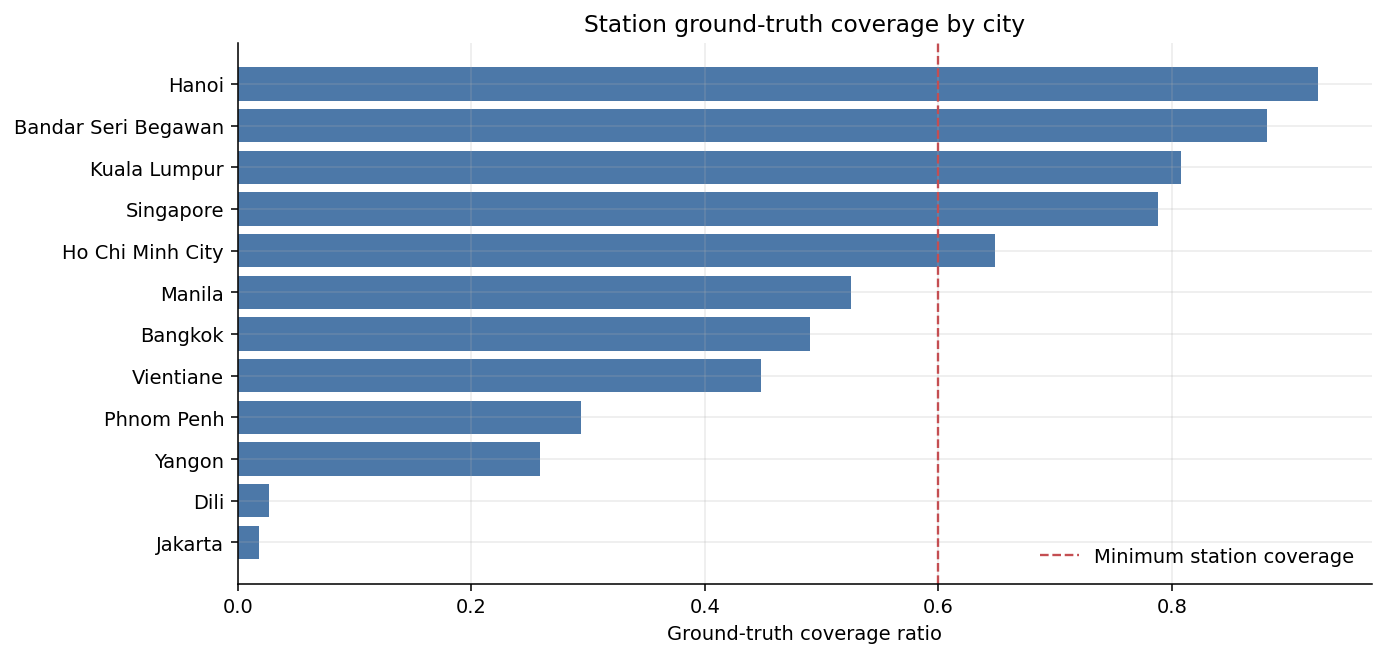

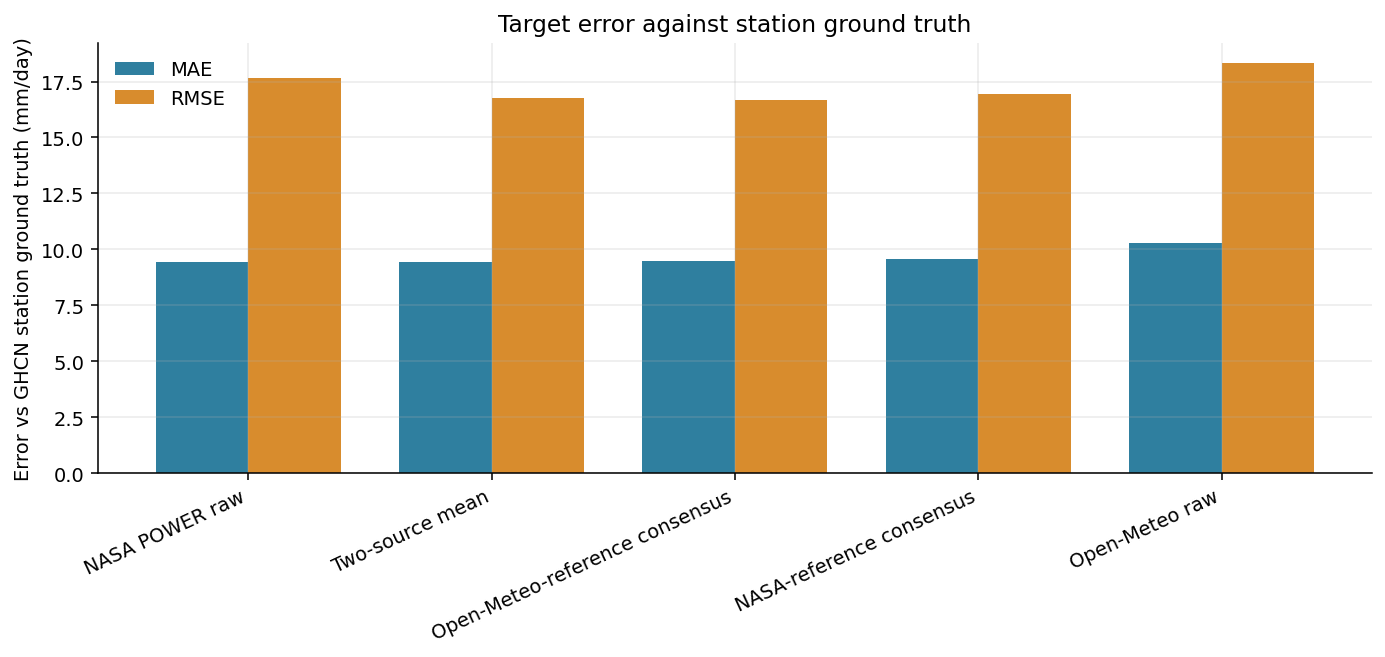

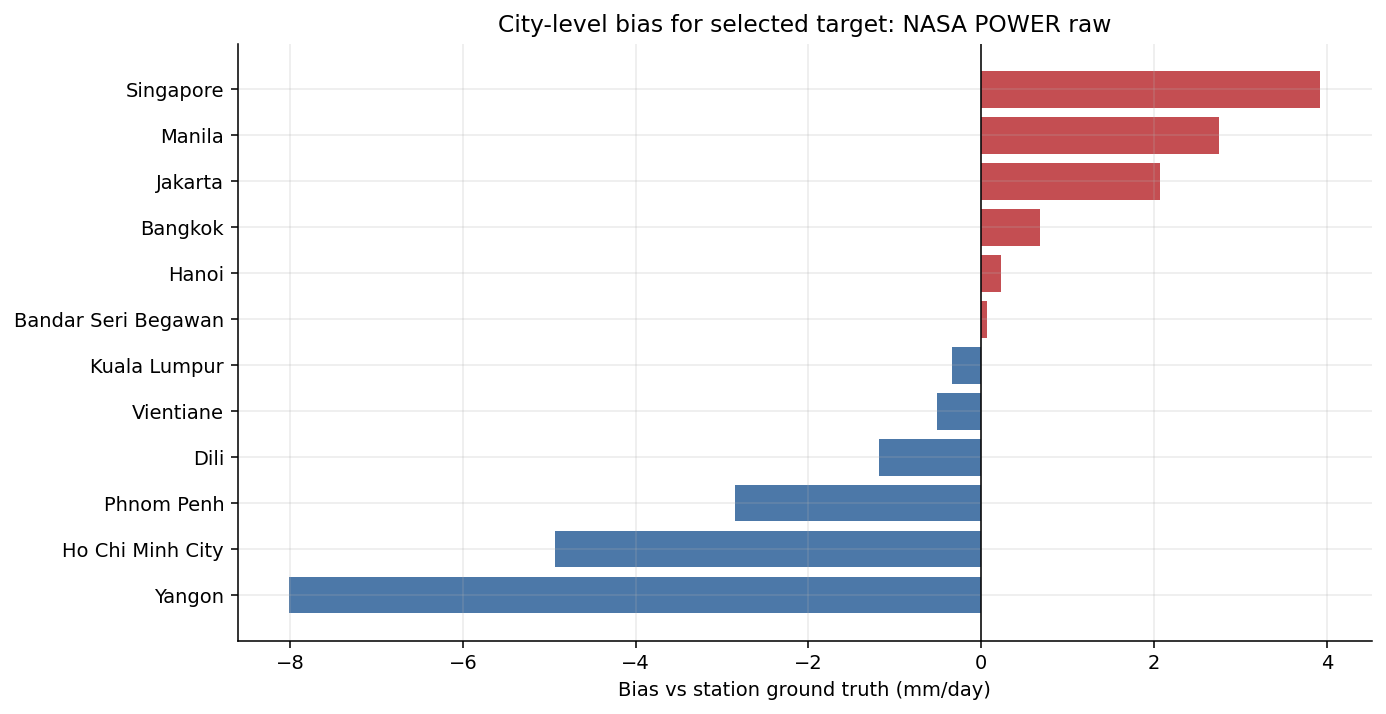

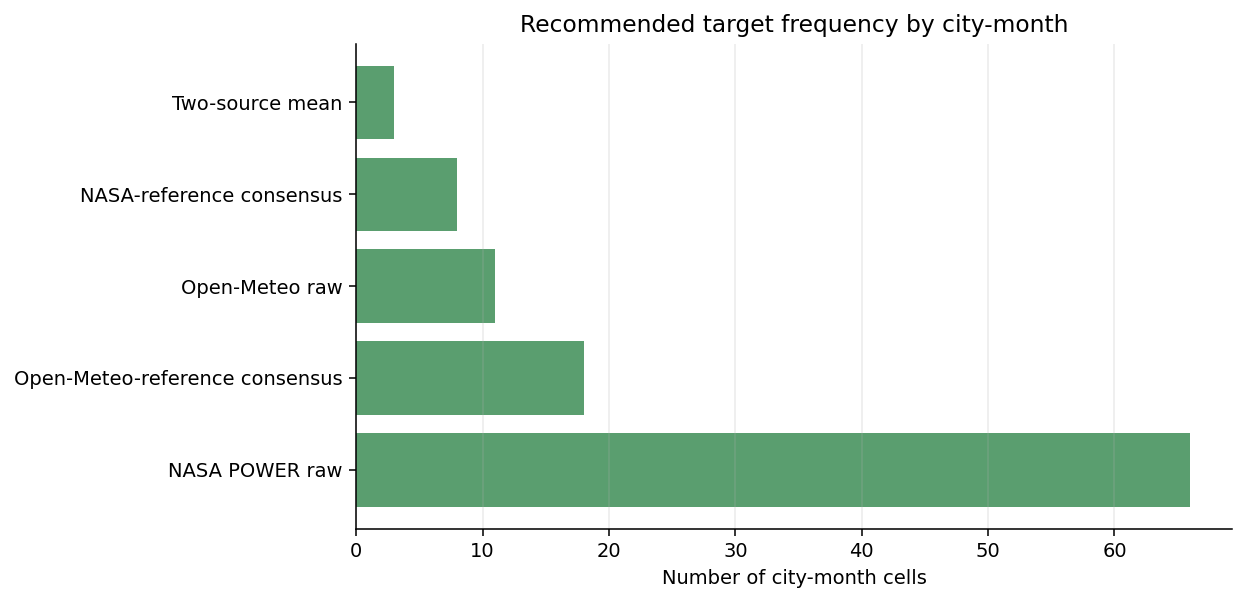

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.8))
coverage_plot = groundtruth_quality_by_entity.sort_values('groundtruth_coverage_ratio')
ax.barh(coverage_plot['location_name'], coverage_plot['groundtruth_coverage_ratio'], color='#4C78A8')
ax.axvline(MIN_STATION_COVERAGE, color='#C44E52', linestyle='--', linewidth=1.2, label='Minimum station coverage')
ax.set_xlabel('Ground-truth coverage ratio')
ax.set_title('Station ground-truth coverage by city')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '01_groundtruth_coverage_by_city.png', bbox_inches='tight')
plt.show()

if not metrics_overall.empty:
    metric_plot = ranked_overall.copy()
    fig, ax = plt.subplots(figsize=(10, 4.8))
    x = np.arange(len(metric_plot))
    width = 0.38
    ax.bar(x - width / 2, metric_plot['mae_mm_day'], width, label='MAE', color='#2F7F9F')
    ax.bar(x + width / 2, metric_plot['rmse_mm_day'], width, label='RMSE', color='#D88C2D')
    ax.set_xticks(x, metric_plot['target_label'], rotation=25, ha='right')
    ax.set_ylabel('Error vs GHCN station ground truth (mm/day)')
    ax.set_title('Target error against station ground truth')
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / '02_target_error_vs_groundtruth_overall.png', bbox_inches='tight')
    plt.show()

    bias_plot = metrics_by_city[metrics_by_city['target'].eq(best_target['target'])].sort_values('bias_mm_day')
    fig, ax = plt.subplots(figsize=(10, 5.2))
    colors = np.where(bias_plot['bias_mm_day'] >= 0, '#C44E52', '#4C78A8')
    ax.barh(bias_plot['location_name'], bias_plot['bias_mm_day'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Bias vs station ground truth (mm/day)')
    ax.set_title(f'City-level bias for selected target: {best_target["target_label"]}')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / '03_selected_target_bias_by_city.png', bbox_inches='tight')
    plt.show()

    if not city_month_recommendation.empty:
        best_counts = city_month_recommendation['recommended_target_label'].value_counts().rename_axis('target_label').reset_index(name='city_month_count')
        fig, ax = plt.subplots(figsize=(9, 4.4))
        ax.barh(best_counts['target_label'], best_counts['city_month_count'], color='#5A9E6F')
        ax.set_xlabel('Number of city-month cells')
        ax.set_title('Recommended target frequency by city-month')
        ax.grid(axis='y', visible=False)
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / '04_recommended_target_frequency_by_city_month.png', bbox_inches='tight')
        plt.show()


## 9. Manifest and Conclusions

In [18]:
collection_finished_at = datetime.now(timezone.utc).isoformat(timespec='seconds')

manifest = {
    'dataset_name': 'Southeast Asia station rainfall ground truth from NOAA GHCN-Daily 2020-2025',
    'created_by_notebook': 'notebooks/06_target_selection_eda_for_model_training.ipynb',
    'collection_finished_at_utc': collection_finished_at,
    'date_range': {'start': START_DATE, 'end': END_DATE, 'frequency': 'daily'},
    'source': {
        'name': 'NOAA GHCN-Daily',
        'base_url': GHCN_BASE_URL,
        'stations_url': GHCN_STATIONS_URL,
        'inventory_url': GHCN_INVENTORY_URL,
        'requires_api_key': False,
        'precipitation_element': 'PRCP',
        'unit_conversion': 'station_precipitation_mm = PRCP / 10',
    },
    'station_selection': {
        'primary_radius_km': PRIMARY_RADIUS_KM,
        'fallback_radius_km': FALLBACK_RADIUS_KM,
        'max_candidate_stations_per_entity': MAX_CANDIDATE_STATIONS_PER_ENTITY,
        'max_selected_stations_per_entity': MAX_SELECTED_STATIONS_PER_ENTITY,
        'minimum_station_coverage': MIN_STATION_COVERAGE,
        'aggregation_method': 'inverse distance weighted daily precipitation over selected stations',
    },
    'row_counts': {
        'station_candidates': int(len(station_candidates)),
        'selected_station_rows': int(len(selected_stations)),
        'station_observation_rows': int(len(station_observations)),
        'entity_groundtruth_rows': int(len(entity_groundtruth)),
        'paired_train_validation_rows': int(len(eval_selection)),
    },
    'files': [],
}

for path in [GROUNDTRUTH_OBSERVATIONS_PATH, GROUNDTRUTH_ENTITY_PATH, GROUNDTRUTH_REGISTRY_PATH]:
    manifest['files'].append({'path': str(path.relative_to(BASE_DIR)), 'sha256': sha256_file(path)})

GROUNDTRUTH_MANIFEST_PATH.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding='utf-8')

if best_target is None:
    conclusion = f'''# Ground-Truth Target Selection Conclusions

## Result
- NOAA GHCN-Daily station data was attempted, but no paired train/validation ground-truth rows were available.
- A primary target cannot be selected from station error yet.

## Next Step
- Inspect station coverage in `tables/05_groundtruth_quality_by_entity.csv`.
- Increase fallback radius or add a regional station source if GHCN coverage is insufficient.
'''
else:
    conclusion = f'''# Ground-Truth Target Selection Conclusions

## Recommended Target
- Primary training target: `{best_target['target']}` ({best_target['target_label']}).
- Selection rule: lowest train/validation MAE against independent NOAA GHCN-Daily station ground truth; tie-broken by RMSE and absolute bias.
- MAE: {best_target['mae_mm_day']:.3f} mm/day.
- RMSE: {best_target['rmse_mm_day']:.3f} mm/day.
- Bias: {best_target['bias_mm_day']:.3f} mm/day.
- Paired train/validation rows: {int(best_target['paired_n'])}.

## Ground-Truth Coverage
- Ground-truth entity-date rows: {len(entity_groundtruth):,}.
- Paired train/validation rows used for target selection: {len(eval_selection):,}.
- Mean city coverage: {groundtruth_quality_by_entity['groundtruth_coverage_ratio'].mean():.3f}.
- Minimum city coverage: {groundtruth_quality_by_entity['groundtruth_coverage_ratio'].min():.3f}.

## Leakage Guard
- Station ground truth is used only as the target-selection reference, not as a model predictor.
- The target decision uses only train and validation rows.
- The test split remains untouched for final model evaluation.

## Output Data
- `data/groundtruth/{GROUNDTRUTH_OBSERVATIONS_PATH.name}`
- `data/groundtruth/{GROUNDTRUTH_ENTITY_PATH.name}`
- `data/groundtruth/{GROUNDTRUTH_REGISTRY_PATH.name}`
- `data/groundtruth/{GROUNDTRUTH_MANIFEST_PATH.name}`
'''

(REPORT_DIR / 'GROUNDTRUTH_TARGET_SELECTION_CONCLUSIONS.md').write_text(conclusion, encoding='utf-8')
print(conclusion)


# Ground-Truth Target Selection Conclusions

## Recommended Target
- Primary training target: `target_nasa_power_precipitation_mm` (NASA POWER raw).
- Selection rule: lowest train/validation MAE against independent NOAA GHCN-Daily station ground truth; tie-broken by RMSE and absolute bias.
- MAE: 9.421 mm/day.
- RMSE: 17.645 mm/day.
- Bias: -0.220 mm/day.
- Paired train/validation rows: 11840.

## Ground-Truth Coverage
- Ground-truth entity-date rows: 26,304.
- Paired train/validation rows used for target selection: 11,840.
- Mean city coverage: 0.509.
- Minimum city coverage: 0.018.

## Leakage Guard
- Station ground truth is used only as the target-selection reference, not as a model predictor.
- The target decision uses only train and validation rows.
- The test split remains untouched for final model evaluation.

## Output Data
- `data/groundtruth/sea_station_rainfall_daily_2020_2025_station_observations.csv`
- `data/groundtruth/sea_station_rainfall_daily_2020_2025_entity_groundtru